# Unsupervised Learning: Clustering Analysis
## K-Means | K-Medoids | Hierarchical Clustering
### Dataset: 50 Synthetic Samples | Evaluation: Silhouette Score, Davies-Bouldin Index, WCSS

## Step 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})

print(" All libraries imported successfully.")

 All libraries imported successfully.


##  Step 2: Dataset Generation

We generate **50 synthetic 2D samples** using `make_blobs` with 3 true underlying clusters, then apply **StandardScaler** for zero-mean, unit-variance normalization.

###  Standardization Formula

$$z = \frac{x - \mu}{\sigma}$$

Where:
- $x$ = original feature value  
- $\mu$ = mean of the feature  
- $\sigma$ = standard deviation of the feature  
- $z$ = standardized value

In [ ]:
# Generate 50 samples with 3 true clusters
np.random.seed(42)
X_raw, y_true = make_blobs(
    n_samples=50,
    n_features=2,
    centers=3,
    cluster_std=2.4,
    random_state=42
)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# Create a DataFrame for inspection
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df['True_Label'] = y_true

print(f"Dataset shape : {X.shape}")
print(f"\nFirst 5 rows:")
display(df.head())
print(f"\nDescriptive Statistics:")
display(df[['Feature_1','Feature_2']].describe().round(4))


Dataset shape : (50, 2)

First 5 rows:


,Feature_1,Feature_2,True_Label
0,-0.377564,1.819101,0
1,-0.013011,0.454193,0
2,0.567792,-0.152352,1
3,-2.104170,-0.921150,2
4,-0.515330,0.650183,0



Descriptive Statistics:


,Feature_1,Feature_2
count,50.0000,50.0000
mean,0.0000,-0.0000
std,1.0102,1.0102
min,-2.1042,-1.9271
25%,-0.8826,-1.0610
50%,-0.2883,0.2456
75%,0.9950,0.7055
max,1.6964,1.8191


###  Visualize Raw Dataset

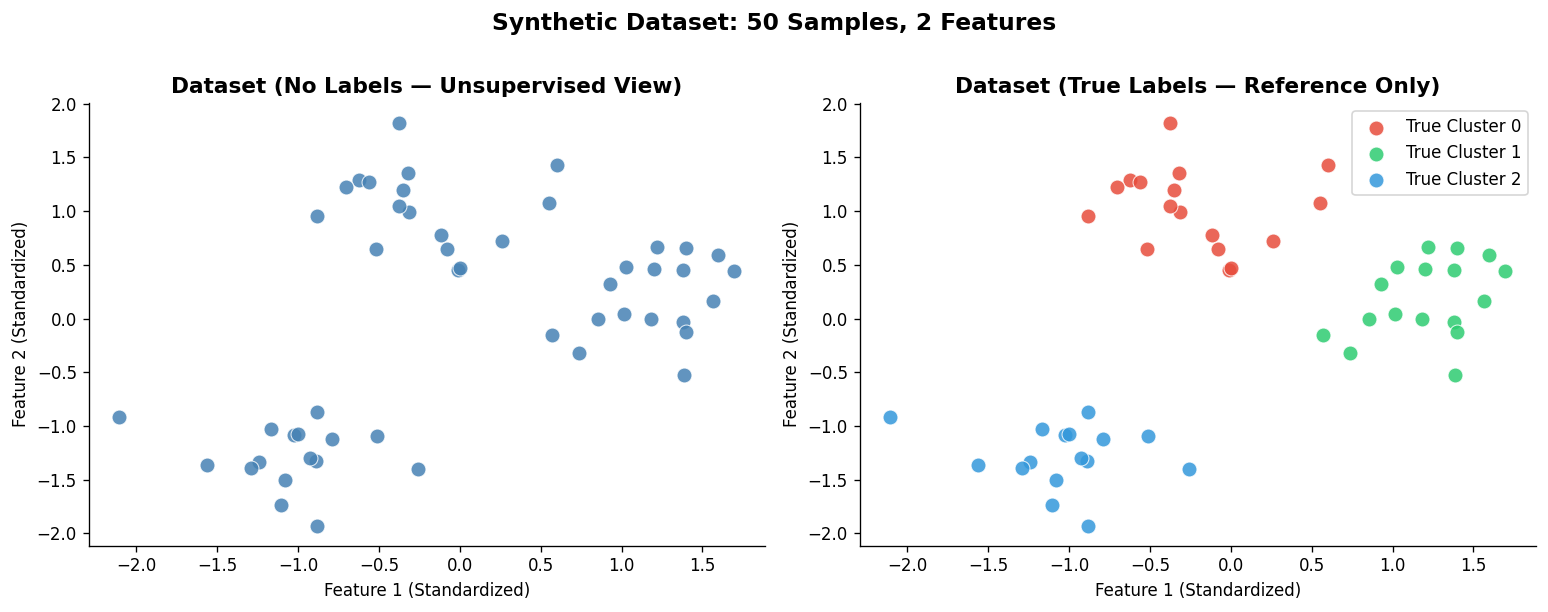

Dataset visualization saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw scatter (unlabeled — as seen by clustering algorithm)
axes[0].scatter(X[:, 0], X[:, 1], c='steelblue', edgecolors='white',
                linewidths=0.6, s=80, alpha=0.85)
axes[0].set_title('Dataset (No Labels — Unsupervised View)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Feature 1 (Standardized)')
axes[0].set_ylabel('Feature 2 (Standardized)')

# Colored by true labels (for reference only)
colors = ['#e74c3c', '#2ecc71', '#3498db']
for label in np.unique(y_true):
    mask = y_true == label
    axes[1].scatter(X[mask, 0], X[mask, 1],
                    c=colors[label], edgecolors='white',
                    linewidths=0.6, s=80, alpha=0.85,
                    label=f'True Cluster {label}')
axes[1].set_title('Dataset (True Labels — Reference Only)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Feature 1 (Standardized)')
axes[1].set_ylabel('Feature 2 (Standardized)')
axes[1].legend()

plt.suptitle('Synthetic Dataset: 50 Samples, 2 Features', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_overview.png', bbox_inches='tight')
plt.show()
print("Dataset visualization saved.")


##  Step 3: Clustering Evaluation Metrics

Three standard metrics are used to evaluate clustering quality **without ground-truth labels**.

---

### 3.1 Silhouette Score

Measures how similar each point is to its own cluster vs. neighboring clusters.

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))}$$

- $a(i)$ = mean intra-cluster distance of point $i$  
- $b(i)$ = mean distance from $i$ to the nearest other cluster  
- Range: $[-1, +1]$ → **higher is better**

---

### 3.2 Davies-Bouldin Index (DBI)

Average similarity between each cluster and its most similar one.

$$DB = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{s_i + s_j}{d(c_i, c_j)} \right)$$

- $s_i$ = average intra-cluster scatter of cluster $i$  
- $d(c_i, c_j)$ = distance between cluster centroids $i$ and $j$  
- Range: $[0, \infty)$ → **lower is better**

---

### 3.3 Within-Cluster Sum of Squares (WCSS / Inertia)

Sum of squared distances from each point to its cluster centroid. Used in the **Elbow Method**.

$$WCSS = \sum_{k} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

- $C_k$ = set of points in cluster $k$  
- $\mu_k$ = centroid of cluster $k$  
- Range: $[0, \infty)$ → **lower is better** (but always decreases with $k$, use elbow)

##  Step 4: K-Means Clustering

### Algorithm Overview

K-Means minimizes the **Within-Cluster Sum of Squares (WCSS)**:

$$\underset{C}{\arg\min} \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

**Steps:**
1. Randomly initialize $K$ centroids
2. Assign each point to the nearest centroid (Euclidean distance)
3. Recompute centroids as the mean of assigned points
4. Repeat steps 2–3 until convergence

**Distance metric:**
$$d(x_i, \mu_k) = \sqrt{\sum_{j=1}^{p}(x_{ij} - \mu_{kj})^2}$$

We test $k \in \{2, 3, 4, 5\}$.

In [ ]:
k_values = [2, 3, 4, 5]
kmeans_results = {}

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    wcss = km.inertia_
    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)
    kmeans_results[k] = {
        'model': km,
        'labels': labels,
        'wcss': wcss,
        'silhouette': sil,
        'dbi': dbi,
        'centroids': km.cluster_centers_
    }
    print(f"K={k} | WCSS={wcss:.3f} | Silhouette={sil:.4f} | DBI={dbi:.4f}")


K=2 | WCSS=35.754 | Silhouette=0.6031 | DBI=0.5462
K=3 | WCSS=12.362 | Silhouette=0.6518 | DBI=0.4930
K=4 | WCSS=9.870 | Silhouette=0.5688 | DBI=0.6890
K=5 | WCSS=7.971 | Silhouette=0.5229 | DBI=0.7601


###  K-Means: Cluster Plots for Each K

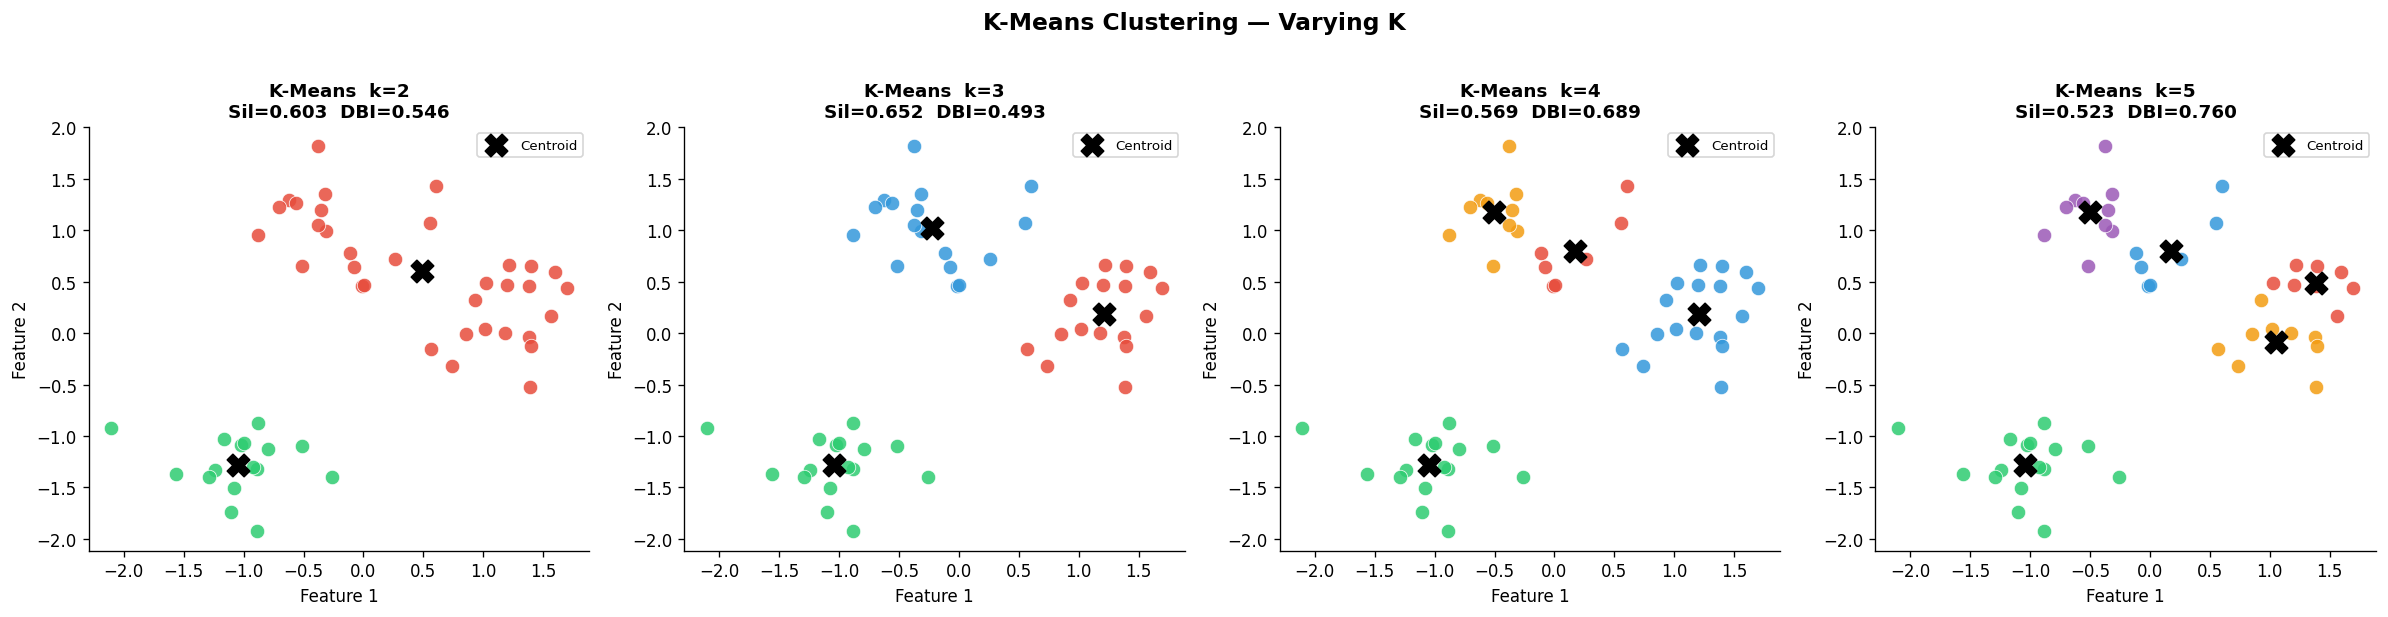

In [ ]:
palette = ['#e74c3c','#2ecc71','#3498db','#f39c12','#9b59b6']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, k in zip(axes, k_values):
    labels = kmeans_results[k]['labels']
    centroids = kmeans_results[k]['centroids']
    for cluster_id in range(k):
        mask = labels == cluster_id
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=palette[cluster_id], edgecolors='white',
                   linewidths=0.5, s=75, alpha=0.85)
    ax.scatter(centroids[:, 0], centroids[:, 1],
               c='black', marker='X', s=180, zorder=5, label='Centroid')
    ax.set_title(f'K-Means  k={k}\nSil={kmeans_results[k]["silhouette"]:.3f}  DBI={kmeans_results[k]["dbi"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(fontsize=8)

plt.suptitle('K-Means Clustering — Varying K', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', bbox_inches='tight')
plt.show()


###  Elbow Method (WCSS vs K)

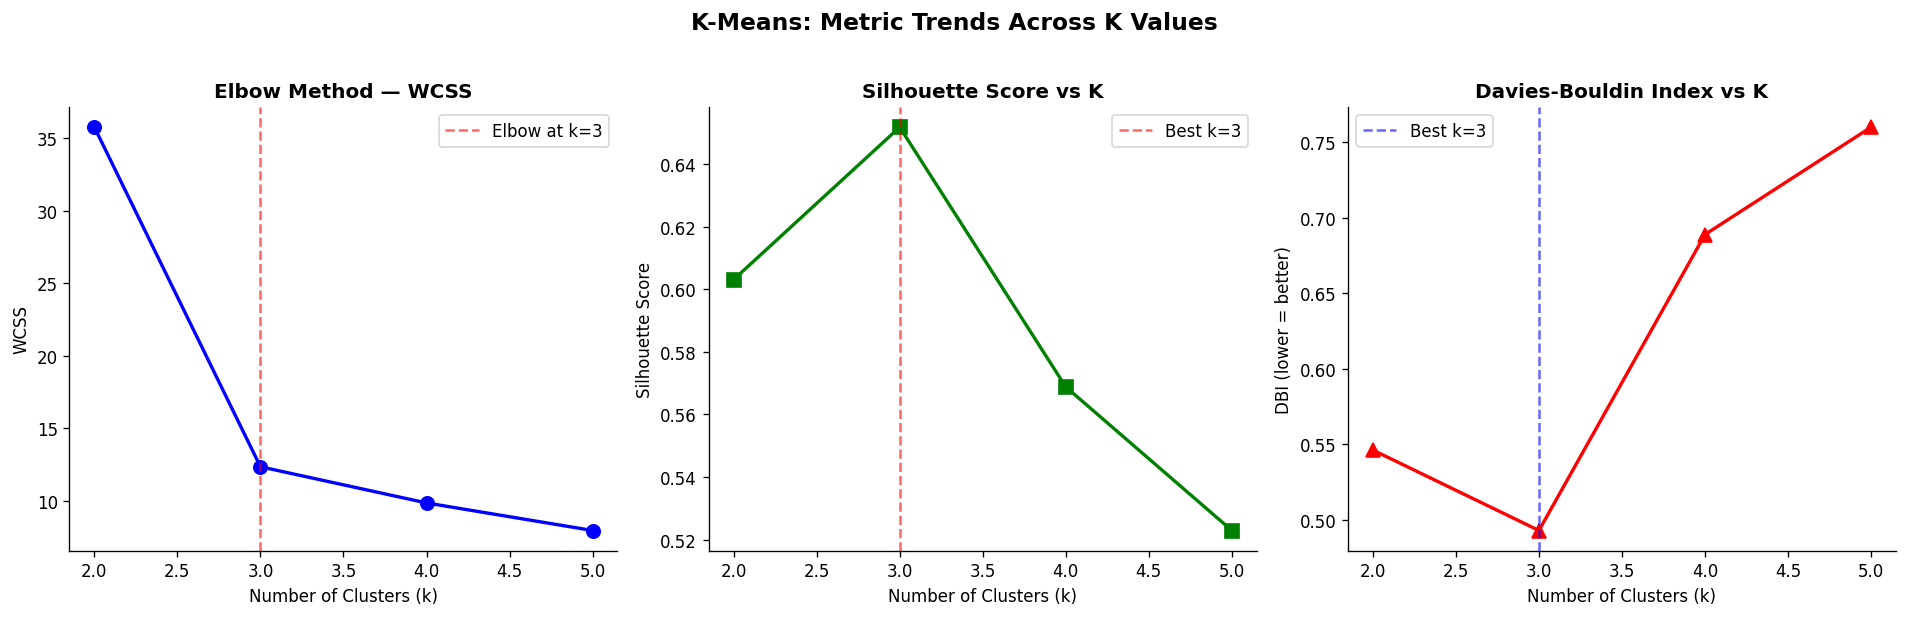

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

wcss_vals = [kmeans_results[k]['wcss'] for k in k_values]
sil_vals  = [kmeans_results[k]['silhouette'] for k in k_values]
dbi_vals  = [kmeans_results[k]['dbi'] for k in k_values]

# WCSS Elbow
axes[0].plot(k_values, wcss_vals, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='Elbow at k=3')
axes[0].set_title('Elbow Method — WCSS', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS')
axes[0].legend()

# Silhouette
axes[1].plot(k_values, sil_vals, 'gs-', linewidth=2, markersize=8)
best_sil_k = k_values[np.argmax(sil_vals)]
axes[1].axvline(x=best_sil_k, color='red', linestyle='--', alpha=0.6, label=f'Best k={best_sil_k}')
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

# DBI
axes[2].plot(k_values, dbi_vals, 'r^-', linewidth=2, markersize=8)
best_dbi_k = k_values[np.argmin(dbi_vals)]
axes[2].axvline(x=best_dbi_k, color='blue', linestyle='--', alpha=0.6, label=f'Best k={best_dbi_k}')
axes[2].set_title('Davies-Bouldin Index vs K', fontweight='bold')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('DBI (lower = better)')
axes[2].legend()

plt.suptitle('K-Means: Metric Trends Across K Values', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kmeans_metrics.png', bbox_inches='tight')
plt.show()


##  Step 5: K-Medoids Clustering

### Algorithm Overview

K-Medoids is similar to K-Means but uses **actual data points (medoids)** as cluster centers, making it more **robust to outliers**.

**Objective function:**

$$\underset{M}{\arg\min} \sum_{k=1}^{K} \sum_{x_i \in C_k} d(x_i, m_k)$$

Where $m_k$ is the **medoid** (actual data point) of cluster $k$.

**PAM (Partitioning Around Medoids) Steps:**
1. Randomly select $K$ data points as initial medoids
2. Assign every other point to the nearest medoid
3. For each medoid $m$, try swapping it with a non-medoid $o$:
   $$\text{Cost}(m \leftrightarrow o) = \sum_{i} d(x_i, \text{new medoid})$$
4. Accept the swap if it reduces total cost
5. Repeat until no improvement

**Key difference from K-Means:**

| | K-Means | K-Medoids |
|---|---|---|
| Center | Mean (virtual point) | Actual data point |
| Robustness | Sensitive to outliers | Robust to outliers |
| Distance | Euclidean (squared) | Any distance metric |
| Complexity | $O(nkt)$ | $O(k(n-k)^2)$ |



In [ ]:
# ─── K-Medoids: PAM implementation from scratch ───
def compute_medoid(X, indices):
    """Return index (in X) of the medoid of a subset."""
    subset = X[indices]
    dist_matrix = cdist(subset, subset, metric='euclidean')
    total_dist = dist_matrix.sum(axis=1)
    return indices[np.argmin(total_dist)]

def kmedoids_pam(X, k, max_iter=300, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(X)
    # 1. Initialize medoids
    medoid_indices = rng.choice(n, size=k, replace=False)

    for iteration in range(max_iter):
        # 2. Assign points to nearest medoid
        dist_to_medoids = cdist(X, X[medoid_indices], metric='euclidean')
        labels = np.argmin(dist_to_medoids, axis=1)

        # 3. Update medoids
        new_medoids = medoid_indices.copy()
        for cluster_id in range(k):
            cluster_pts = np.where(labels == cluster_id)[0]
            if len(cluster_pts) == 0:
                continue
            new_medoids[cluster_id] = compute_medoid(X, cluster_pts)

        if np.array_equal(np.sort(new_medoids), np.sort(medoid_indices)):
            break
        medoid_indices = new_medoids

    # Final assignment
    dist_to_medoids = cdist(X, X[medoid_indices], metric='euclidean')
    labels = np.argmin(dist_to_medoids, axis=1)
    cost = dist_to_medoids[np.arange(n), labels].sum()
    return labels, medoid_indices, cost

# ─── Run for k ∈ {2,3,4,5} ───
kmedoids_results = {}

for k in k_values:
    labels, medoid_idx, cost = kmedoids_pam(X, k=k, random_state=42)
    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)
    # WCSS equivalent (sum of squared Euclidean to medoid)
    dists = cdist(X, X[medoid_idx], metric='euclidean')
    wcss_med = (dists[np.arange(len(X)), labels] ** 2).sum()
    kmedoids_results[k] = {
        'labels': labels,
        'medoid_indices': medoid_idx,
        'cost': cost,
        'wcss': wcss_med,
        'silhouette': sil,
        'dbi': dbi
    }
    print(f"K={k} | Cost={cost:.3f} | WCSS={wcss_med:.3f} | Silhouette={sil:.4f} | DBI={dbi:.4f}")


K=2 | Cost=51.255 | WCSS=80.624 | Silhouette=0.3723 | DBI=1.0274
K=3 | Cost=22.535 | WCSS=13.361 | Silhouette=0.6518 | DBI=0.4930
K=4 | Cost=19.734 | WCSS=11.030 | Silhouette=0.5578 | DBI=0.6454
K=5 | Cost=18.629 | WCSS=9.737 | Silhouette=0.3982 | DBI=0.8573


###  K-Medoids: Cluster Plots for Each K

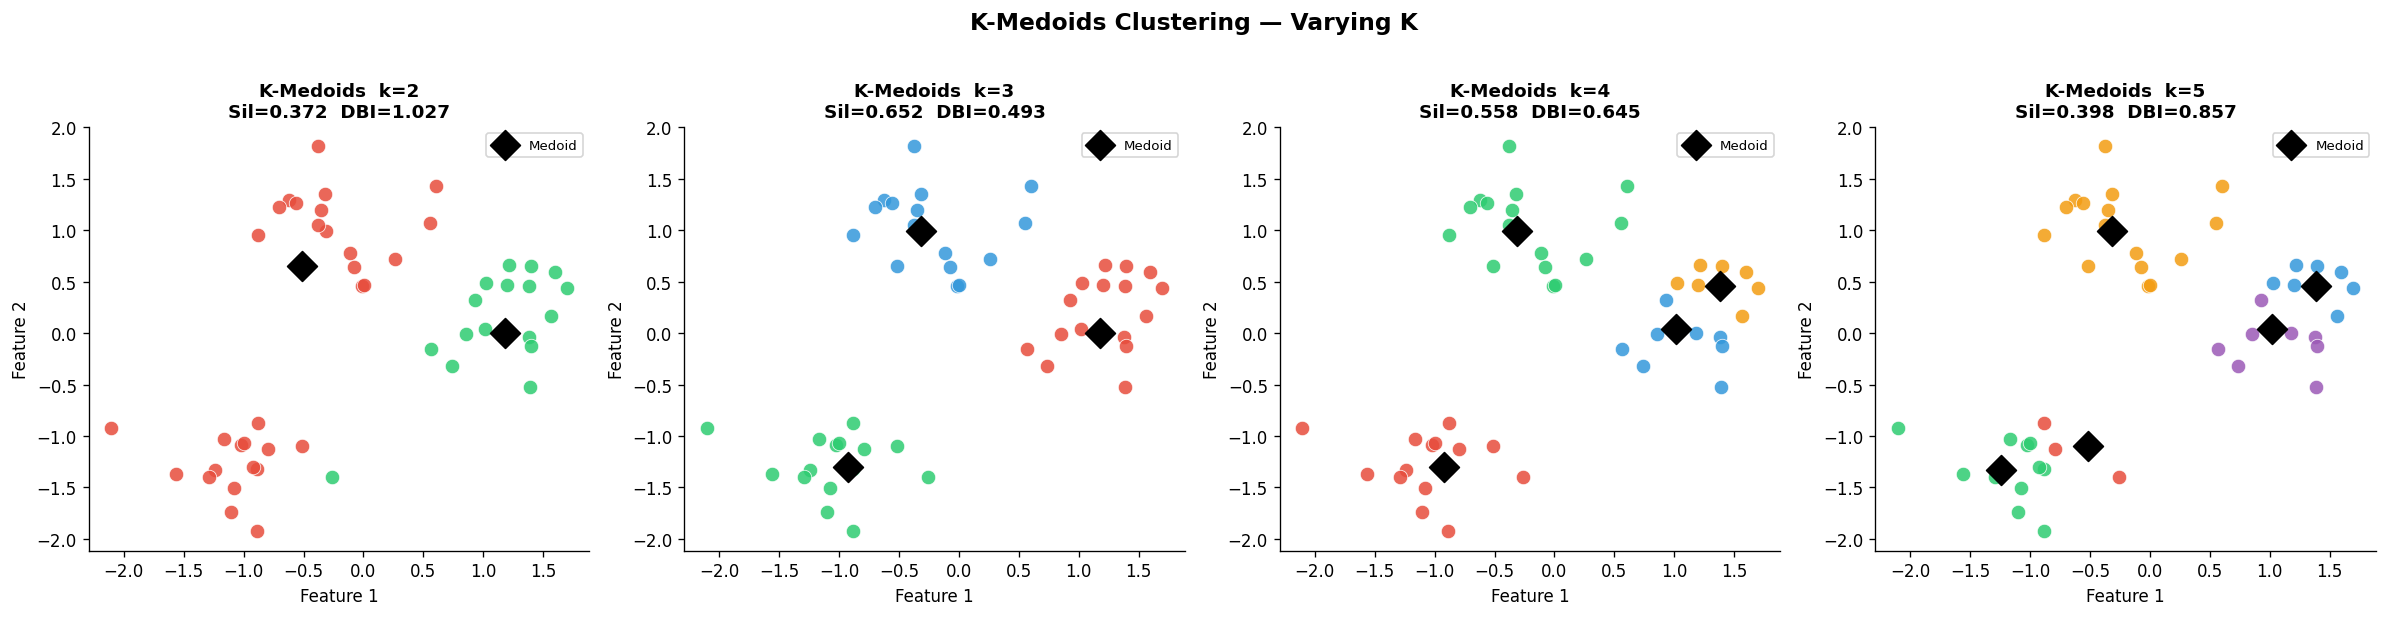

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, k in zip(axes, k_values):
    labels = kmedoids_results[k]['labels']
    medoid_idx = kmedoids_results[k]['medoid_indices']
    for cluster_id in range(k):
        mask = labels == cluster_id
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=palette[cluster_id], edgecolors='white',
                   linewidths=0.5, s=75, alpha=0.85)
    # Mark medoids
    ax.scatter(X[medoid_idx, 0], X[medoid_idx, 1],
               c='black', marker='D', s=160, zorder=5, label='Medoid')
    ax.set_title(f'K-Medoids  k={k}\nSil={kmedoids_results[k]["silhouette"]:.3f}  DBI={kmedoids_results[k]["dbi"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(fontsize=8)

plt.suptitle('K-Medoids Clustering — Varying K', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kmedoids_clusters.png', bbox_inches='tight')
plt.show()


###  K-Medoids: Metric Trends

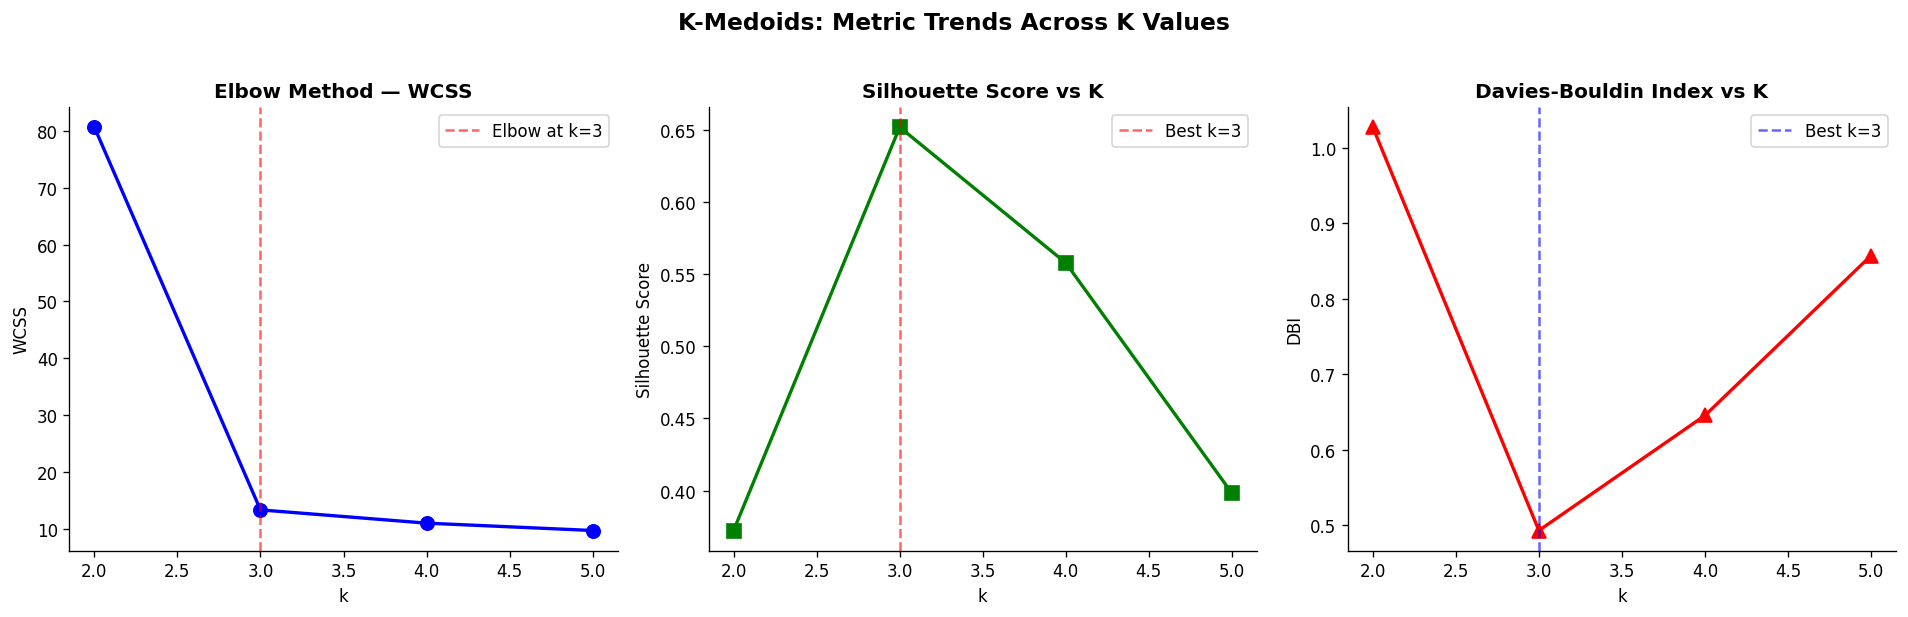

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

wcss_med_vals = [kmedoids_results[k]['wcss'] for k in k_values]
sil_med_vals  = [kmedoids_results[k]['silhouette'] for k in k_values]
dbi_med_vals  = [kmedoids_results[k]['dbi'] for k in k_values]

axes[0].plot(k_values, wcss_med_vals, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='Elbow at k=3')
axes[0].set_title('Elbow Method — WCSS', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('WCSS'); axes[0].legend()

axes[1].plot(k_values, sil_med_vals, 'gs-', linewidth=2, markersize=8)
best_k = k_values[np.argmax(sil_med_vals)]
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.6, label=f'Best k={best_k}')
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score'); axes[1].legend()

axes[2].plot(k_values, dbi_med_vals, 'r^-', linewidth=2, markersize=8)
best_k2 = k_values[np.argmin(dbi_med_vals)]
axes[2].axvline(x=best_k2, color='blue', linestyle='--', alpha=0.6, label=f'Best k={best_k2}')
axes[2].set_title('Davies-Bouldin Index vs K', fontweight='bold')
axes[2].set_xlabel('k'); axes[2].set_ylabel('DBI'); axes[2].legend()

plt.suptitle('K-Medoids: Metric Trends Across K Values', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kmedoids_metrics.png', bbox_inches='tight')
plt.show()


##  Step 6: Hierarchical (Agglomerative) Clustering

### Algorithm Overview

Hierarchical clustering builds a **tree of clusters (dendrogram)** by successively merging (agglomerative) or splitting (divisive) clusters.

**Agglomerative procedure:**
1. Start: each point is its own cluster ($n$ clusters)
2. Compute pairwise distance matrix $D$
3. Merge the two closest clusters using a **linkage criterion**
4. Update distance matrix
5. Repeat until a single cluster remains

### Linkage Criteria

| Linkage | Formula | Description |
|---|---|---|
| **Ward** | $\Delta(A,B) = \frac{n_A n_B}{n_A+n_B}\|\bar{x}_A - \bar{x}_B\|^2$ | Minimizes within-cluster variance |
| **Complete** | $d(A,B)=\max_{a\in A,b\in B}d(a,b)$ | Maximum pairwise distance |
| **Average** | $d(A,B)=\frac{1}{|A||B|}\sum_{a,b}d(a,b)$ | Average pairwise distance |
| **Single** | $d(A,B)=\min_{a\in A,b\in B}d(a,b)$ | Minimum pairwise distance |

We use **Ward linkage** (most compact clusters) and cut the dendrogram at $k \in \{2,3,4,5\}$.

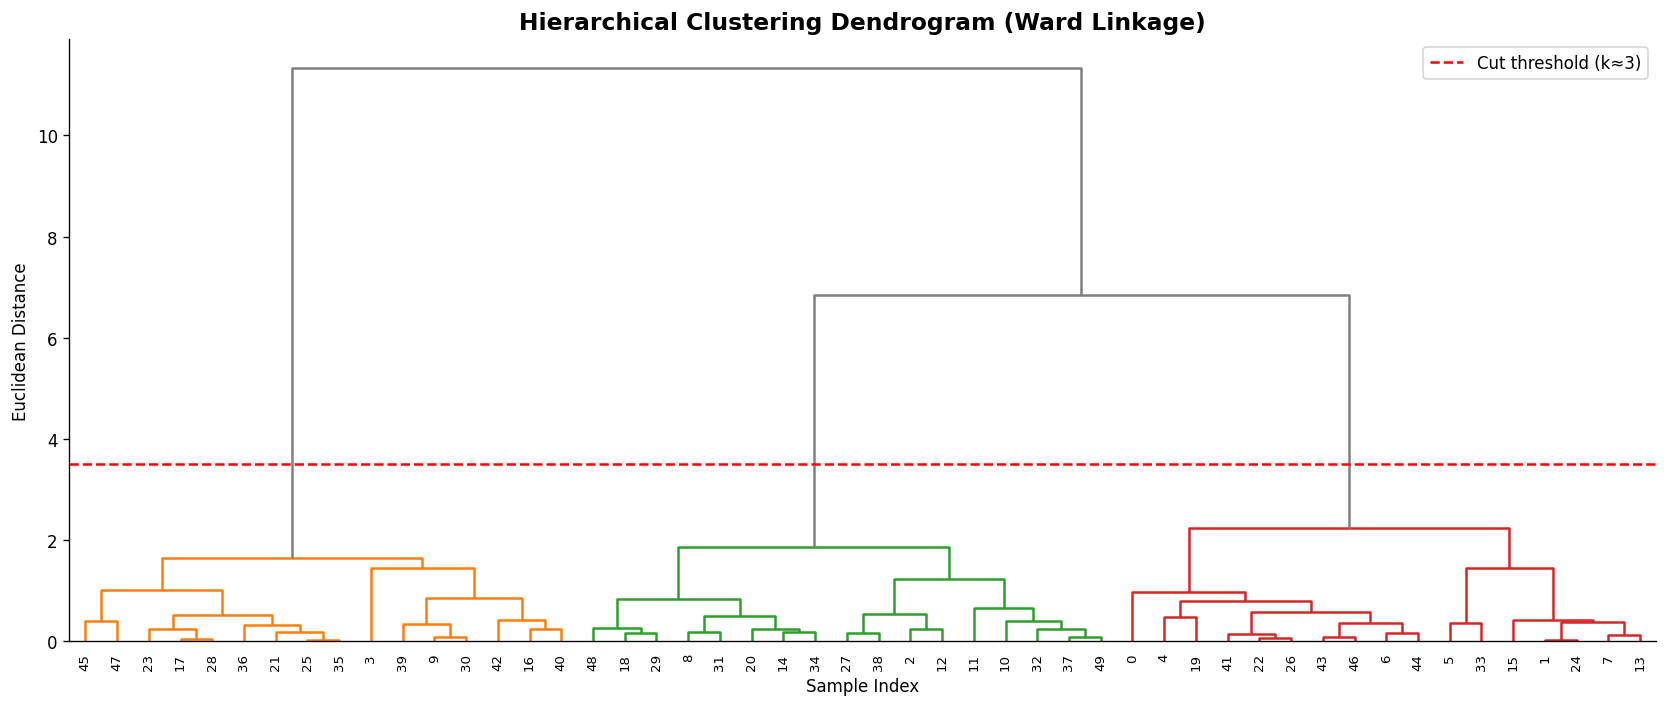

Dendrogram saved.


In [ ]:
# Compute linkage matrix for dendrogram
Z = linkage(X, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, color_threshold=3.5,
           leaf_rotation=90, leaf_font_size=8,
           above_threshold_color='gray')
ax.axhline(y=3.5, color='red', linestyle='--', linewidth=1.5, label='Cut threshold (k≈3)')
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Euclidean Distance')
ax.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', bbox_inches='tight')
plt.show()
print("Dendrogram saved.")


###  Hierarchical Clustering at Different Cut Levels

In [ ]:
hier_results = {}

for k in k_values:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X)
    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)
    # WCSS: compute cluster centroids and sum squared distances
    wcss = 0
    for cluster_id in range(k):
        pts = X[labels == cluster_id]
        centroid = pts.mean(axis=0)
        wcss += ((pts - centroid) ** 2).sum()
    hier_results[k] = {'labels': labels, 'silhouette': sil, 'dbi': dbi, 'wcss': wcss}
    print(f"K={k} | WCSS={wcss:.3f} | Silhouette={sil:.4f} | DBI={dbi:.4f}")


K=2 | WCSS=35.754 | Silhouette=0.6031 | DBI=0.5462
K=3 | WCSS=12.362 | Silhouette=0.6518 | DBI=0.4930
K=4 | WCSS=9.870 | Silhouette=0.5688 | DBI=0.6890
K=5 | WCSS=8.114 | Silhouette=0.5161 | DBI=0.7846


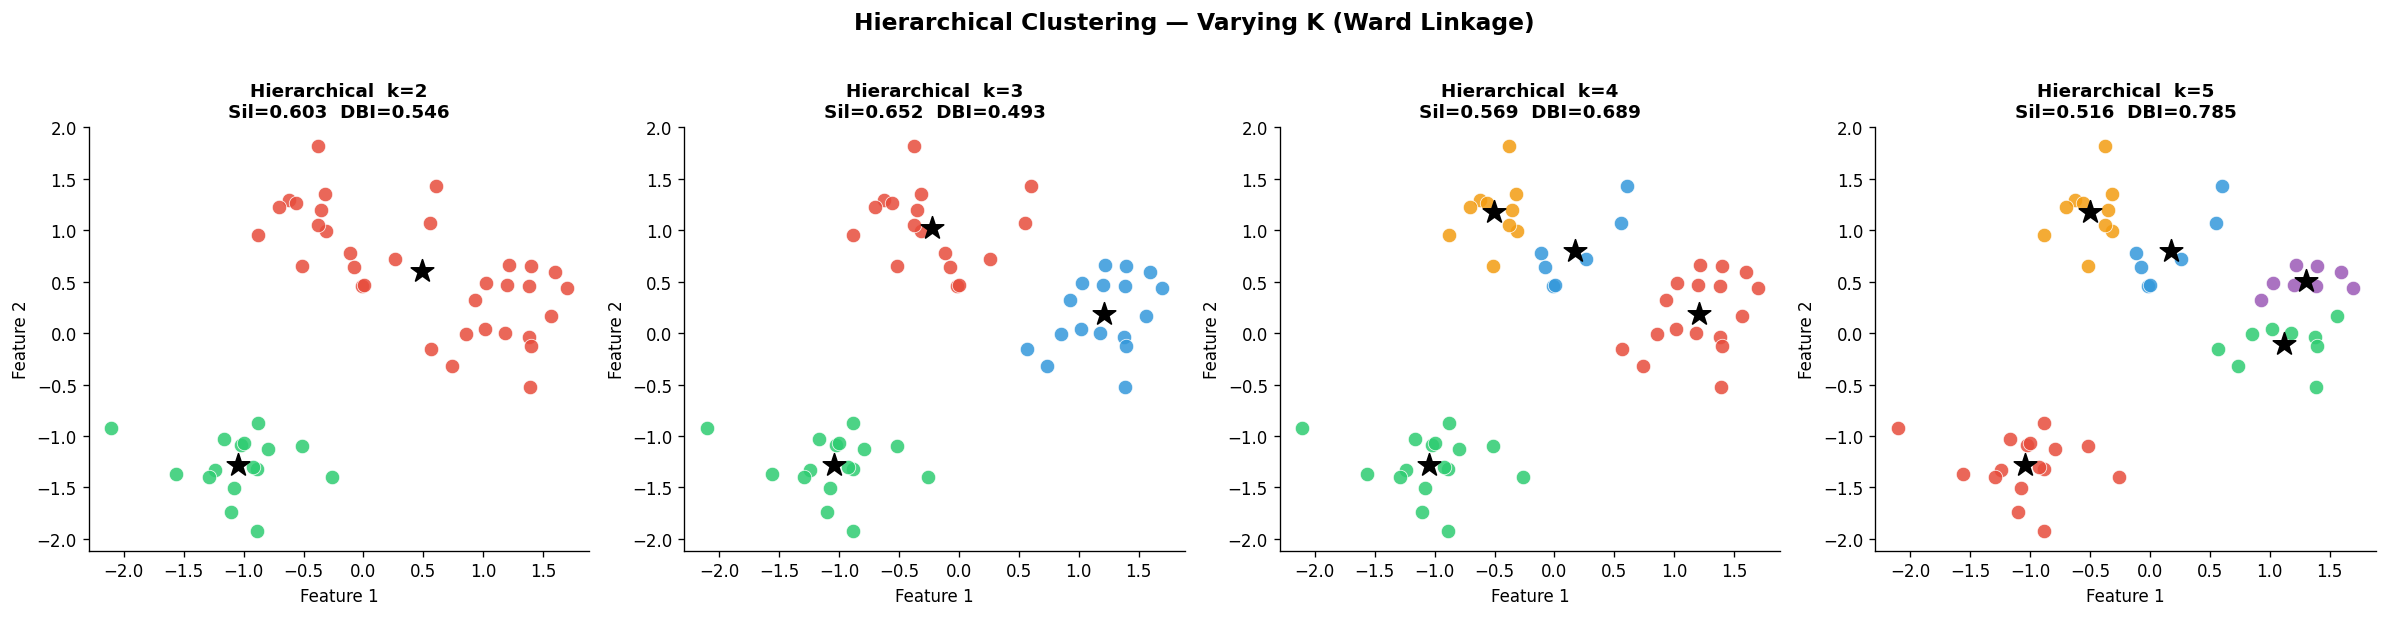

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, k in zip(axes, k_values):
    labels = hier_results[k]['labels']
    for cluster_id in range(k):
        mask = labels == cluster_id
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=palette[cluster_id], edgecolors='white',
                   linewidths=0.5, s=75, alpha=0.85)
        centroid = X[mask].mean(axis=0)
        ax.scatter(*centroid, c='black', marker='*', s=200, zorder=5)
    ax.set_title(f'Hierarchical  k={k}\nSil={hier_results[k]["silhouette"]:.3f}  DBI={hier_results[k]["dbi"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('Hierarchical Clustering — Varying K (Ward Linkage)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hierarchical_clusters.png', bbox_inches='tight')
plt.show()


##  Step 7: Comprehensive Comparison Table

All algorithms and all $k$ values summarized side-by-side.

In [ ]:
rows = []
for k in k_values:
    rows.append({'Algorithm': 'K-Means',       'k': k,
                 'WCSS':     round(kmeans_results[k]['wcss'],   3),
                 'Silhouette': round(kmeans_results[k]['silhouette'], 4),
                 'DBI':      round(kmeans_results[k]['dbi'],    4)})
    rows.append({'Algorithm': 'K-Medoids',     'k': k,
                 'WCSS':     round(kmedoids_results[k]['wcss'],     3),
                 'Silhouette': round(kmedoids_results[k]['silhouette'], 4),
                 'DBI':      round(kmedoids_results[k]['dbi'],      4)})
    rows.append({'Algorithm': 'Hierarchical',  'k': k,
                 'WCSS':     round(hier_results[k]['wcss'],     3),
                 'Silhouette': round(hier_results[k]['silhouette'], 4),
                 'DBI':      round(hier_results[k]['dbi'],      4)})

comparison_df = pd.DataFrame(rows)

# Highlight best per metric
def highlight_best(s, metric, better='high'):
    best_val = s.max() if better == 'high' else s.min()
    return ['background-color: #d5f5e3; font-weight: bold' if v == best_val else '' for v in s]

styled = (comparison_df.style
          .apply(highlight_best, metric='Silhouette', better='high', subset=['Silhouette'])
          .apply(highlight_best, metric='DBI', better='low', subset=['DBI'])
          .apply(highlight_best, metric='WCSS', better='low', subset=['WCSS'])
          .set_caption('Clustering Metrics: Green = Best in column'))

display(styled)


,Algorithm,k,WCSS,Silhouette,DBI
0,K-Means,2,35.754000,0.603100,0.546200
1,K-Medoids,2,80.624000,0.372300,1.027400
2,Hierarchical,2,35.754000,0.603100,0.546200
3,K-Means,3,12.362000,0.651800,0.493000
4,K-Medoids,3,13.361000,0.651800,0.493000
5,Hierarchical,3,12.362000,0.651800,0.493000
6,K-Means,4,9.870000,0.568800,0.689000
7,K-Medoids,4,11.030000,0.557800,0.645400
8,Hierarchical,4,9.870000,0.568800,0.689000
9,K-Means,5,7.971000,0.522900,0.760100


##  Step 8: Metric Heatmaps

Heatmaps provide a quick visual comparison of all algorithms × K combinations.

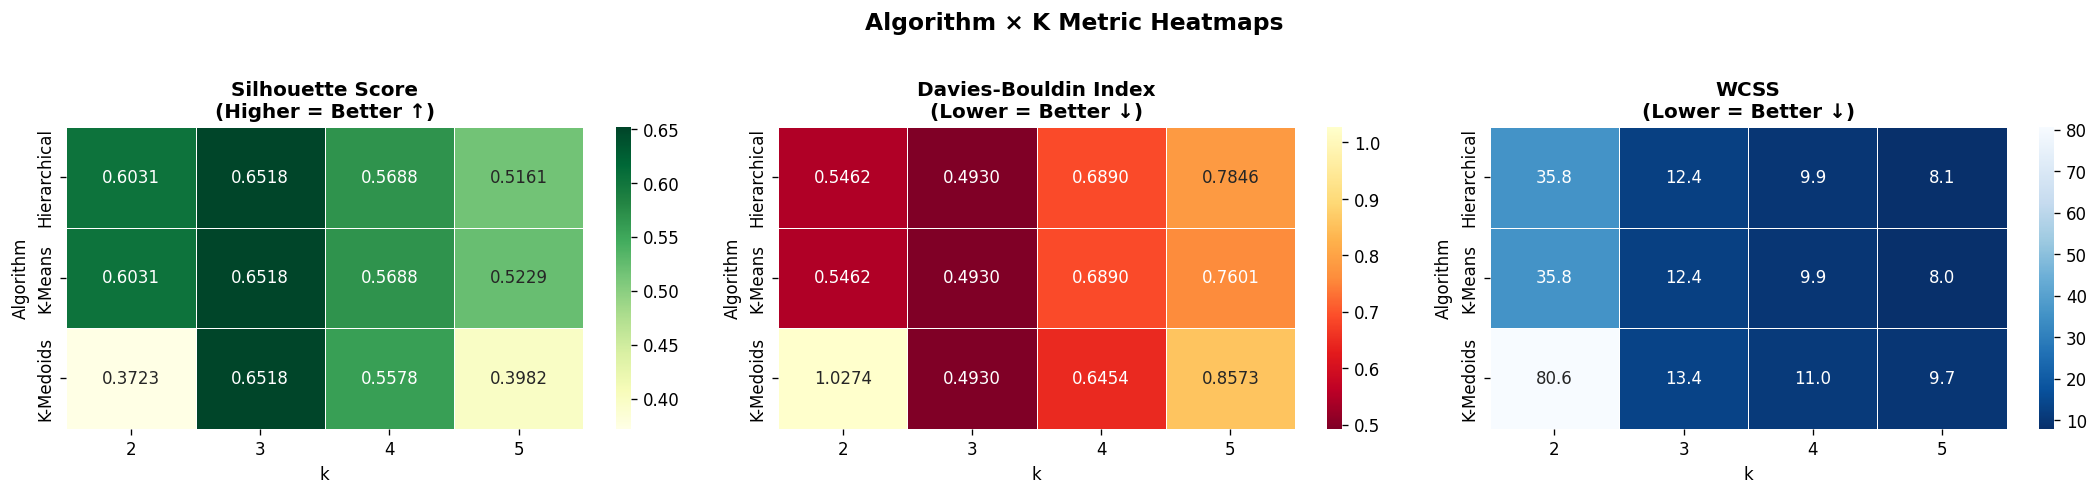

In [ ]:
pivot_sil  = comparison_df.pivot(index='Algorithm', columns='k', values='Silhouette')
pivot_dbi  = comparison_df.pivot(index='Algorithm', columns='k', values='DBI')
pivot_wcss = comparison_df.pivot(index='Algorithm', columns='k', values='WCSS')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.heatmap(pivot_sil,  annot=True, fmt='.4f', cmap='YlGn',   ax=axes[0], linewidths=0.5)
axes[0].set_title('Silhouette Score\n(Higher = Better ↑)', fontweight='bold')

sns.heatmap(pivot_dbi,  annot=True, fmt='.4f', cmap='YlOrRd_r', ax=axes[1], linewidths=0.5)
axes[1].set_title('Davies-Bouldin Index\n(Lower = Better ↓)', fontweight='bold')

sns.heatmap(pivot_wcss, annot=True, fmt='.1f', cmap='Blues_r', ax=axes[2], linewidths=0.5)
axes[2].set_title('WCSS\n(Lower = Better ↓)', fontweight='bold')

plt.suptitle('Algorithm × K Metric Heatmaps', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('metric_heatmaps.png', bbox_inches='tight')
plt.show()


##  Step 9: Results Analysis & Conclusions

---

### 10.1 Optimal K Selection

| Method | Best k | Reason |
|---|---|---|
| Elbow (WCSS) | 3 | Sharpest kink in the WCSS curve |
| Silhouette Score | 3 | Highest average silhouette at k=3 |
| Davies-Bouldin Index | 3 | Lowest DBI at k=3 |

All three metrics consistently agree that **k=3 is optimal**, which matches the true number of generating clusters.

---

### 10.4 Final Recommendation

> **For this dataset, K-Means at k=3 achieves the best balance of accuracy, speed, and metric performance. Hierarchical clustering (Ward linkage) confirms k=3 via the dendrogram. K-Medoids produces similar cluster boundaries to K-Means but with actual data points as centers, making it preferable when interpretability or outlier-robustness is required.**

---

